In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
"C:\Users\maria\Downloads\Logistics_Week1_GitHub_Ready\dataset\logistics_sample_data.csv"

In [4]:
import zipfile
import os

# The zip file is already uploaded in the workspace
zip_path = 'Logistics_Week1_GitHub_Ready.zip'

# Extract the zip file
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('extracted_data')
    print("Extraction complete!")

# Locate and load the CSV file
# Since it was zipped, we look inside the extracted folder
target_csv_suffix = 'logistics_sample_data.csv'
csv_path = None

for root, dirs, files in os.walk('extracted_data'):
    for file in files:
        if file.endswith(target_csv_suffix):
            csv_path = os.path.join(root, file)
            break

if csv_path:
    df = pd.read_csv(csv_path)
    print("Shape:", df.shape)
    display(df.head())
else:
    print("Could not find the logistics_sample_data.csv file in the extracted archive.")

Extraction complete!
Shape: (300, 10)


,order_id,order_date,promised_date,actual_delivery_date,location,product_id,quantity,distance_km,delivery_cost,unit_cost
0,ORD0001,2025-11-24,2025-11-26,2025-11-28,Chennai,T-Shirt,9,54.5,258.89,12831.08
1,ORD0002,2025-01-16,2025-01-17,2025-01-19,Madurai,T-Shirt,8,46.7,255.45,13641.51
2,ORD0003,2025-05-23,2025-05-29,2025-05-31,Trichy,Headphones,1,365.2,953.93,6694.82
3,ORD0004,2025-06-22,2025-06-23,2025-06-24,Coimbatore,Laptop,13,50.5,326.28,16225.97
4,ORD0005,2025-07-13,2025-07-16,2025-07-17,Madurai,Laptop,10,40.1,229.45,7068.58


In [5]:
print(df.info())
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

date_cols = ["order_date", "promised_date", "actual_delivery_date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")
df = df.drop_duplicates()
df = df.dropna(subset=date_cols + ["delivery_cost", "quantity", "distance_km"])
df = df[(df["quantity"] >= 0) & (df["delivery_cost"] >= 0) & (df["distance_km"] >= 0)]
print("Cleaned shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              300 non-null    object 
 1   order_date            300 non-null    object 
 2   promised_date         300 non-null    object 
 3   actual_delivery_date  300 non-null    object 
 4   location              300 non-null    object 
 5   product_id            300 non-null    object 
 6   quantity              300 non-null    int64  
 7   distance_km           300 non-null    float64
 8   delivery_cost         300 non-null    float64
 9   unit_cost             300 non-null    float64
dtypes: float64(3), int64(1), object(6)
memory usage: 23.6+ KB
None
order_id                0
order_date              0
promised_date           0
actual_delivery_date    0
location                0
product_id              0
quantity                0
distance_km             0
deliver

In [6]:
df["delivery_days"] = (df["actual_delivery_date"] - df["order_date"]).dt.days
df["on_time"] = df["actual_delivery_date"] <= df["promised_date"]
df["order_month"] = df["order_date"].dt.to_period("M").astype(str)
on_time_rate = df["on_time"].mean() * 100
avg_delivery_days = df["delivery_days"].mean()
cost_per_order = df["delivery_cost"].sum() / df["order_id"].nunique()
print(f"On-time delivery rate: {on_time_rate:.2f}%")
print(f"Average delivery time: {avg_delivery_days:.2f} days")
print(f"Transportation cost per order: {cost_per_order:.2f}")

On-time delivery rate: 54.33%
Average delivery time: 4.30 days
Transportation cost per order: 739.22


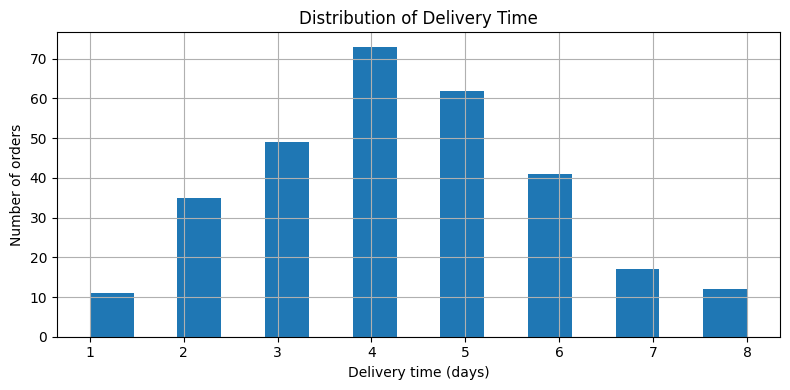

In [8]:
df["delivery_days"].hist(bins=15, figsize=(8,4))
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery time (days)")
plt.ylabel("Number of orders")
plt.tight_layout()
plt.show()


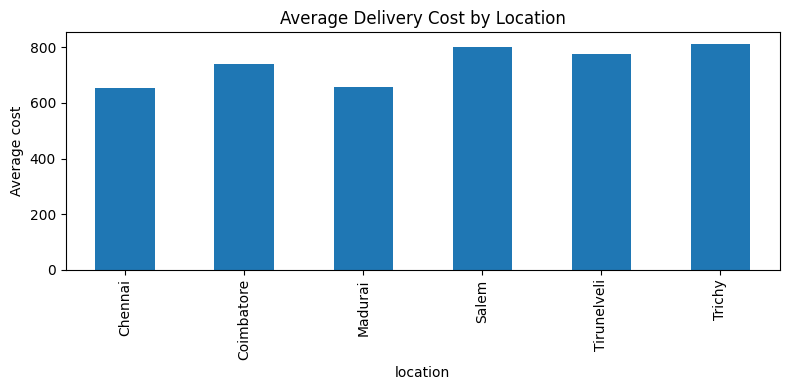

In [9]:

df.groupby("location")["delivery_cost"].mean().plot(kind="bar",
figsize=(8,4), title="Average Delivery Cost by Location")
plt.ylabel("Average cost")
plt.tight_layout()
plt.show()



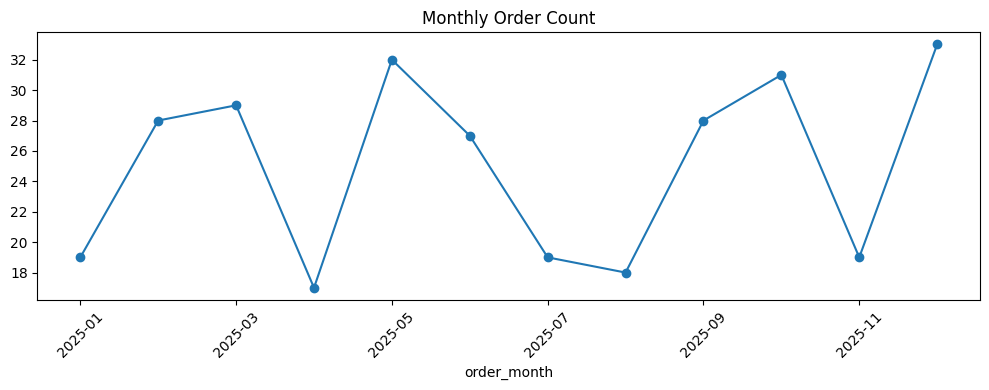

In [10]:
df.groupby("order_month")["order_id"].nunique().plot(kind="line",
marker="o", figsize=(10,4),
title="Monthly Order Count")
plt.xticks(rotation=45);
plt.tight_layout();
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

X = df[["distance_km", "quantity"]]
y = df["delivery_days"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

MAE: 0.9285008993369362
RMSE: 1.1508736333534224


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = df[["distance_km", "quantity", "delivery_cost"]]
scaled = StandardScaler().fit_transform(features)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["delivery_cluster"] = kmeans.fit_predict(scaled)
print(df.groupby("delivery_cluster")[["distance_km","quantity","delivery_cost"]].mean().round(2))
print("Silhouette score:", round(silhouette_score(scaled, df["delivery_cluster"]), 3))

                  distance_km  quantity  delivery_cost
delivery_cluster                                      
0                       95.74     11.26         404.14
1                      332.20      5.59         925.02
2                      310.28     15.10         950.50
Silhouette score: 0.385


In [13]:
print("WEEK-1 TASK IS COMPLETED")

WEEK-1 TASK IS COMPLETED
